# BAW Notebook 01: Target Structure Analysis

**Purpose:** Load any protein structure, locate a region of interest from a few
seed residues, collect all surface-exposed residues around it into a candidate
pool, and export clean files for downstream tools (RFdiffusion, ProteinMPNN,
Boltz-2).

**Input:** One or two PDB files (primary target + optional alternate/comparison structure)

**Output:**
- Cleaned target PDB (selected chain only, no waters/ligands)
- Epitope centre of mass
- Candidate residue pool for binder design (`<label>_hotspot_residues.json`)
- Epitope analysis figure
- Optional: residue-level comparison between two structures

**Workflow (set in Cell 2):**
- **Seed residues** — a few residue numbers that locate the region of interest in 3D space
- **Sphere radius** — how far around the seed centre to collect candidate residues
- **SASA threshold** — minimum relative surface exposure for a residue to qualify

Cell 4c builds an interactive candidate pool from these settings. Notebook 00
(the Bayesian controller) then explores combinations of the pool to choose the
final hotspots; that decision no longer lives in this notebook.


In [1]:
# Cell 1: Imports and popup helpers

import os
import sys
import json
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from scipy.spatial.distance import pdist, squareform

from Bio.PDB import PDBParser, PPBuilder, PDBIO, Select, NeighborSearch

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')

# --------------------------------------------------------------------------
# Shared plotting palette -- kept consistent with Notebook 00a
# --------------------------------------------------------------------------
CATEGORY_COLORS = {
    'catalytic':   '#C0392B',   # deep red
    'hydrophobic': '#E67E22',   # orange
    'surface':     '#2980B9',   # blue
    'polar':       '#27AE60',   # green
    'unknown':     '#95A5A6',   # grey
}
SASA_COLORMAP = 'RdYlGn'  # red=buried, green=exposed
CATEGORY_SASA = {
    'A_consistently_exposed': '#2ECC71',
    'B_mostly_exposed':       '#F39C12',
    'C_variable':             '#E74C3C',
    'D_mostly_buried':        '#95A5A6',
    'missing':                '#BDC3C7',
}

# --------------------------------------------------------------------------
# Popup helpers -- native Windows dialogs via PowerShell (WSL interop)
# --------------------------------------------------------------------------
def ps_browse_file(title='Select file', filter_str='PDB files|*.pdb|JSON files|*.json|All files|*.*'):
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.OpenFileDialog
$d.Title = "{title}"
$d.Filter = "{filter_str}"
$d.ShowDialog() | Out-Null
Write-Output $d.FileName
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script], capture_output=True, text=True)
    p = r.stdout.strip()
    if not p:
        return None
    w = subprocess.run(["wslpath", p], capture_output=True, text=True)
    return w.stdout.strip() or None

def ps_browse_folder(title='Select folder'):
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.FolderBrowserDialog
$d.Description = "{title}"
$d.ShowNewFolderButton = $true
$d.ShowDialog() | Out-Null
Write-Output $d.SelectedPath
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script], capture_output=True, text=True)
    p = r.stdout.strip()
    if not p:
        return None
    w = subprocess.run(["wslpath", p], capture_output=True, text=True)
    return w.stdout.strip() or None

def ps_multiline_input(title='Input', prompt='Enter data:', default_text='', width=700, height=550):
    safe = default_text.replace('"', '`"').replace('\n', '`r`n')
    bw, bh = width - 110, height - 80
    cw, ch = width - 210, height - 80
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
Add-Type -AssemblyName System.Drawing
$f = New-Object System.Windows.Forms.Form
$f.Text = "{title}"; $f.Size = New-Object System.Drawing.Size({width},{height})
$f.StartPosition = "CenterScreen"; $f.TopMost = $true
$lb = New-Object System.Windows.Forms.Label
$lb.Text = "{prompt}"; $lb.Location = New-Object System.Drawing.Point(10,10)
$lb.Size = New-Object System.Drawing.Size({width-30},30); $f.Controls.Add($lb)
$tb = New-Object System.Windows.Forms.TextBox
$tb.Multiline = $true; $tb.ScrollBars = "Vertical"
$tb.Location = New-Object System.Drawing.Point(10,45)
$tb.Size = New-Object System.Drawing.Size({width-30},{height-130})
$tb.Font = New-Object System.Drawing.Font("Consolas",10)
$tb.Text = "{safe}"; $f.Controls.Add($tb)
$ok = New-Object System.Windows.Forms.Button
$ok.Text = "Confirm"; $ok.Location = New-Object System.Drawing.Point({bw},{bh})
$ok.Size = New-Object System.Drawing.Size(90,32)
$ok.DialogResult = [System.Windows.Forms.DialogResult]::OK; $f.Controls.Add($ok)
$ca = New-Object System.Windows.Forms.Button
$ca.Text = "Cancel"; $ca.Location = New-Object System.Drawing.Point({cw},{ch})
$ca.Size = New-Object System.Drawing.Size(90,32)
$ca.DialogResult = [System.Windows.Forms.DialogResult]::Cancel; $f.Controls.Add($ca)
$f.AcceptButton = $ok; $f.CancelButton = $ca
if ($f.ShowDialog() -eq [System.Windows.Forms.DialogResult]::OK) {{ Write-Output $tb.Text }}
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script], capture_output=True, text=True)
    return r.stdout.strip()

print('Imports loaded.')
print(f'BioPython PDB parser ready.')
print(f'NumPy {np.__version__}, pandas {pd.__version__}')


Imports loaded.
BioPython PDB parser ready.
NumPy 1.26.4, pandas 2.3.3


In [2]:
# Cell 2: Configuration form
#
# Fill in the fields and click Confirm Configuration.
# All later cells read the variables this cell sets.
# Nothing is hardcoded. Change values and re-run this cell at any time.

import ipywidgets as widgets
from IPython.display import display, clear_output

W = dict(style={'description_width': '210px'})

target_name_w = widgets.Text(
    value='Trans-sialidase', description='Target name:',
    layout=widgets.Layout(width='470px'), **W)

target_label_w = widgets.Text(
    value='ts', description='File label (short):',
    placeholder='used in filenames, e.g. ts / spike',
    layout=widgets.Layout(width='470px'), **W)

target_chain_w = widgets.Text(
    value='A', description='Chain ID:',
    placeholder='confirmed in Cell 4',
    layout=widgets.Layout(width='320px'), **W)

# Seed residues locate the region of interest in 3D space.
seed_residues_w = widgets.Text(
    value='342,119,312',
    description='Seed residues (locate the region):',
    placeholder='e.g. 311,119,312',
    layout=widgets.Layout(width='560px'), **W)

# Radius (A) around the seed residues to collect candidate residues.
sphere_radius_w = widgets.FloatSlider(
    value=18.0, min=5.0, max=40.0, step=0.5,
    description='Sphere radius (A):', readout_format='.1f',
    layout=widgets.Layout(width='470px'), **W)

# Minimum relative SASA for a residue to be considered surface-exposed.
sasa_threshold_w = widgets.FloatSlider(
    value=0.15, min=0.05, max=0.50, step=0.01,
    description='Surface exposure threshold (SASA):', readout_format='.2f',
    layout=widgets.Layout(width='470px'), **W)

# Kept for geometry calculations downstream (Cells 6/7).
epitope_radius_w = widgets.FloatSlider(
    value=15.0, min=5.0, max=30.0, step=0.5,
    description='Epitope radius (A):', readout_format='.1f',
    layout=widgets.Layout(width='470px'), **W)

# --- Confirm button ---
confirm_btn = widgets.Button(
    description='Confirm Configuration',
    button_style='success',
    layout=widgets.Layout(width='230px', height='36px'))
conf_out = widgets.Output()

def _parse_seed(text):
    seeds = []
    for part in text.split(','):
        part = part.strip()
        if not part:
            continue
        try:
            seeds.append(int(part))
        except ValueError:
            pass
    return seeds

def on_confirm(_):
    global TARGET_NAME, TARGET_LABEL, TARGET_CHAIN
    global SEED_RESIDUES, SPHERE_RADIUS, SASA_THRESHOLD, EPITOPE_RADIUS

    TARGET_NAME    = target_name_w.value.strip()
    TARGET_LABEL   = target_label_w.value.strip()
    TARGET_CHAIN   = target_chain_w.value.strip().upper() or 'A'
    SPHERE_RADIUS  = sphere_radius_w.value
    SASA_THRESHOLD = sasa_threshold_w.value
    EPITOPE_RADIUS = epitope_radius_w.value
    SEED_RESIDUES  = _parse_seed(seed_residues_w.value)

    with conf_out:
        clear_output()
        print('Configuration confirmed.')
        print(f'  Target         : {TARGET_NAME}  (label: {TARGET_LABEL})')
        print(f'  Chain          : {TARGET_CHAIN}  (confirm in Cell 4)')
        print(f'  Seed residues  : {SEED_RESIDUES}')
        print(f'  Sphere radius  : {SPHERE_RADIUS} A')
        print(f'  SASA threshold : {SASA_THRESHOLD}')
        print(f'  Epitope radius : {EPITOPE_RADIUS} A')
        print()
        if not SEED_RESIDUES:
            print('WARNING: no valid seed residues parsed. Enter comma-separated numbers.')
        print('Ready -- run Cell 3 to select your PDB files.')

confirm_btn.on_click(on_confirm)

# --- Assemble form ---
form = widgets.VBox([
    widgets.HTML('<h3 style="margin-bottom:8px">Notebook 01 -- Configuration</h3>'),
    target_name_w,
    target_label_w,
    target_chain_w,
    widgets.HTML('<hr style="margin:10px 0">'),
    seed_residues_w,
    sphere_radius_w,
    sasa_threshold_w,
    epitope_radius_w,
    widgets.HTML('<hr style="margin:10px 0">'),
    confirm_btn,
    conf_out,
])

# Initialise variables from widget defaults so later cells do not crash
# if Confirm has not been clicked yet in this session.
TARGET_NAME    = target_name_w.value.strip()
TARGET_LABEL   = target_label_w.value.strip()
TARGET_CHAIN   = target_chain_w.value.strip().upper()
SPHERE_RADIUS  = sphere_radius_w.value
SASA_THRESHOLD = sasa_threshold_w.value
EPITOPE_RADIUS = epitope_radius_w.value
SEED_RESIDUES  = _parse_seed(seed_residues_w.value)

display(form)


In [3]:
# Cell 3: Select PDB files via popup

out = widgets.Output()
display(out)

# --- Primary structure ---
with out:
    print(f'Select the PRIMARY structure PDB for {TARGET_NAME}...')

primary_pdb_path = ps_browse_file(
    title=f'Select PRIMARY structure PDB ({TARGET_NAME})',
    filter_str='PDB files|*.pdb|All files|*.*'
)

with out:
    if primary_pdb_path:
        print(f'  Primary: {primary_pdb_path}')
    else:
        raise FileNotFoundError('No primary structure selected. Re-run this cell.')

# --- Optional alternate/comparison structure ---
with out:
    print(f'\nOptionally select an ALTERNATE structure for comparison.')
    print(f'  (e.g. apo vs holo, wild-type vs mutant, active vs inactive)')
    print(f'  Cancel if you only have one structure.')

alternate_pdb_path = ps_browse_file(
    title='Select ALTERNATE structure (or Cancel to skip)',
    filter_str='PDB files|*.pdb|All files|*.*'
)

with out:
    if alternate_pdb_path:
        print(f'  Alternate: {alternate_pdb_path}')
    else:
        print(f'  Alternate: skipped')

# --- Output directory ---
with out:
    print('\nSelect output directory for analysis files...')

output_dir_str = ps_browse_folder(title='Select output directory')

with out:
    if output_dir_str:
        output_dir = Path(output_dir_str)
    else:
        output_dir = Path.home() / 'BasementAntibodyWorks' / 'data' / TARGET_LABEL
        print(f'  (using default: {output_dir})')

output_dir.mkdir(parents=True, exist_ok=True)

with out:
    print(f'  Output dir: {output_dir}')
    print('\nAll paths set.')


Output()

In [5]:
# Cell 4: Load structure and pick chain

parser = PDBParser(QUIET=True)
ppb    = PPBuilder()

structure = parser.get_structure(TARGET_LABEL, primary_pdb_path)
model     = structure[0]

print(f'{TARGET_NAME.upper()} STRUCTURE')
print('=' * 60)
print(f'File  : {Path(primary_pdb_path).name}')
print(f'Models: {len(structure)}')
print()

chain_summary = []
for chain in model:
    cid = chain.get_id()
    protein_res = [r for r in chain if r.get_id()[0] == ' ']
    hetatm_res  = [r for r in chain if r.get_id()[0] not in (' ', 'W')]
    water_res   = [r for r in chain if r.get_id()[0] == 'W']

    seq = ''
    for pp in ppb.build_peptides(chain):
        seq += str(pp.get_sequence())

    res_range = ''
    if protein_res:
        first = protein_res[0].get_id()[1]
        last  = protein_res[-1].get_id()[1]
        res_range = f'{first}–{last}'

    ligands = set(r.get_resname() for r in hetatm_res)

    print(f'Chain {cid}:')
    print(f'  Protein residues : {len(protein_res)}  ({res_range})')
    print(f'  Sequence length  : {len(seq)}')
    print(f'  HETATM residues  : {len(hetatm_res)} {ligands if ligands else ""}')
    print(f'  Waters           : {len(water_res)}')
    print()

    chain_summary.append({'id': cid, 'n_residues': len(protein_res), 'seq_len': len(seq)})

# ---- Chain picker widget ----
chain_ids   = [c['id'] for c in chain_summary]
default_idx = chain_ids.index(TARGET_CHAIN) if TARGET_CHAIN in chain_ids else 0

chain_picker = widgets.Dropdown(
    options=chain_ids,
    value=chain_ids[default_idx],
    description='Work with chain:',
    style={'description_width': 'initial'},
)

confirm_btn  = widgets.Button(description='Confirm chain', button_style='success')
chain_output = widgets.Output()

def on_confirm(_):
    global TARGET_CHAIN, working_chain
    TARGET_CHAIN  = chain_picker.value
    working_chain = model[TARGET_CHAIN]
    with chain_output:
        clear_output()
        print(f'Chain {TARGET_CHAIN} selected. {len([r for r in working_chain if r.get_id()[0]==" "])} protein residues.')

confirm_btn.on_click(on_confirm)
display(widgets.HBox([chain_picker, confirm_btn]), chain_output)

# Initialise silently so later cells work even if button is not clicked
TARGET_CHAIN  = chain_ids[default_idx]
working_chain = model[TARGET_CHAIN]


TRANS-SIALIDASE STRUCTURE
File  : 1MS3.pdb
Models: 1

Chain A:
  Protein residues : 623  (1–632)
  Sequence length  : 623
  HETATM residues  : 0 
  Waters           : 595

Chain B:
  Protein residues : 623  (1–632)
  Sequence length  : 623
  HETATM residues  : 0 
  Waters           : 557



Output()

In [6]:
# Cell 4b: Surface-exposed residues (SASA)
#
# Computes solvent-accessible surface area for every residue in the selected
# chain using BioPython's Shrake-Rupley algorithm, and records each residue's
# CA coordinates. This feeds the candidate-pool search in Cell 4c.
#
# If a multi-structure consensus SASA file already exists (produced by
# Notebook 00a), load the candidate pool from it instead of recomputing SASA
# from this single structure.

from Bio.PDB.SASA import ShrakeRupley
import numpy as np

SASA_THRESHOLD_VAL = SASA_THRESHOLD  # from Cell 2

consensus_json_path = output_dir / f'{TARGET_LABEL}_consensus_sasa.json'

if consensus_json_path.exists():
    print(f'Loading consensus SASA from Notebook 00a: {consensus_json_path}')
    with open(consensus_json_path) as f:
        consensus_data = json.load(f)

    sasa_records = []
    for pos_str, data in consensus_data['region_data'].items():
        sasa_records.append({
            'res_num': int(pos_str),
            'res_name': data['uniprot_residue'],
            'sasa': data['mean_sasa'],
            'relative_sasa': data['mean_sasa'],
            'exposed': data['mean_sasa'] >= SASA_THRESHOLD_VAL,
            'x': 0.0, 'y': 0.0, 'z': 0.0,
        })
    sasa_df = pd.DataFrame(sasa_records)

    consensus_pool = consensus_data.get('candidate_pool_A', [])

    print(f'Consensus SASA loaded.')
    print(f'Region residues     : {len(sasa_df)}')
    print(f'Category A pool     : {consensus_pool}')
    print()
    print('Skipping single-structure SASA calculation.')
    print('Using multi-structure consensus from Notebook 00a.')

else:
    print(f'No consensus SASA found at {consensus_json_path}')
    print('Running single-structure SASA calculation...')
    print()

    sr = ShrakeRupley()
    sr.compute(structure, level="R")

    sasa_data = []
    for residue in working_chain:
        if residue.get_id()[0] != ' ' or 'CA' not in residue:
            continue
        res_num = residue.get_id()[1]
        res_name = residue.get_resname()
        sasa = getattr(residue, 'sasa', 0.0)
        ca_coords = residue['CA'].get_vector().get_array()
        sasa_data.append({
            'res_num': res_num,
            'res_name': res_name,
            'sasa': sasa,
            'x': ca_coords[0],
            'y': ca_coords[1],
            'z': ca_coords[2],
        })

    sasa_df = pd.DataFrame(sasa_data)
    max_sasa = sasa_df['sasa'].max()
    sasa_df['relative_sasa'] = sasa_df['sasa'] / (max_sasa + 1e-9)
    sasa_df['exposed'] = sasa_df['relative_sasa'] >= SASA_THRESHOLD_VAL

    print(f'SASA ANALYSIS — {TARGET_NAME} chain {TARGET_CHAIN}')
    print(f'Total residues     : {len(sasa_df)}')
    print(f'Surface-exposed    : {sasa_df["exposed"].sum()} ({100*sasa_df["exposed"].mean():.0f}%)')
    print(f'Buried             : {(~sasa_df["exposed"]).sum()}')
    print()
    print('Top 20 most exposed residues:')
    display(sasa_df.sort_values('sasa', ascending=False).head(20)[['res_num','res_name','sasa','relative_sasa']].round(3))


Loading consensus SASA from Notebook 00a: /mnt/c/Antibody Design/ts_consensus_sasa.json
Consensus SASA loaded.
Region residues     : 132
Category A pool     : [55, 117, 248, 249, 281, 308, 311, 337, 361]

Skipping single-structure SASA calculation.
Using multi-structure consensus from Notebook 00a.


In [7]:
# Cell 4c: Candidate residue pool
#
# Finds all surface-exposed residues within SPHERE_RADIUS of the seed residues,
# asks for any force-include residues via popup, shows an interactive checkbox
# table, and locks in the candidate pool on Confirm.
# This pool is what Notebook 00 (the Bayesian controller) explores.

# ── Update coordinates if loaded from consensus (Cell 4b sets x=y=z=0) ──────
if (sasa_df['x'] == 0).all() and (sasa_df['y'] == 0).all():
    print('Updating coordinates from PDB structure...')
    coord_updates = []
    for _, row in sasa_df.iterrows():
        res_num = int(row['res_num'])
        try:
            residue = working_chain[(' ', res_num, ' ')]
            ca = residue['CA'].get_vector().get_array()
            coord_updates.append({
                'res_num': res_num,
                'x': float(ca[0]),
                'y': float(ca[1]),
                'z': float(ca[2])
            })
        except KeyError:
            coord_updates.append({
                'res_num': res_num,
                'x': 0.0, 'y': 0.0, 'z': 0.0
            })
    coord_df = pd.DataFrame(coord_updates).set_index('res_num')
    sasa_df = sasa_df.set_index('res_num')
    sasa_df.update(coord_df)
    sasa_df = sasa_df.reset_index()
    print(f'Coordinates updated for {len(coord_updates)} residues.')

# ── Parse seed residues ──────────────────────────────────────────────────────
seed_res_nums = SEED_RESIDUES  # list of ints from Cell 2

seed_coords = []
for res_num in seed_res_nums:
    try:
        res = working_chain[(' ', res_num, ' ')]
        seed_coords.append(res['CA'].get_vector().get_array())
    except KeyError:
        print(f'WARNING: seed residue {res_num} not found in chain {TARGET_CHAIN}')

if not seed_coords:
    raise ValueError('No seed residues found. Check residue numbers match the PDB.')

seed_centre = np.mean(seed_coords, axis=0)

# ── Collect residues within sphere ───────────────────────────────────────────
in_sphere = []
for _, row in sasa_df.iterrows():
    coord = np.array([row['x'], row['y'], row['z']])
    dist = np.linalg.norm(coord - seed_centre)
    in_sphere.append(dist <= SPHERE_RADIUS)

sasa_df['in_sphere'] = in_sphere
sasa_df['dist_to_centre'] = sasa_df.apply(
    lambda r: np.linalg.norm(np.array([r['x'], r['y'], r['z']]) - seed_centre),
    axis=1)

# ── Ask user for force-include residues via popup ────────────────────────────
# These bypass the SASA filter — useful for functionally important residues
# that are partially buried in this crystal form (e.g. Tyr119, Trp312 in 1S0I
# which are occluded by the substrate in the Michaelis complex structure).

_fi_script = """
Add-Type -AssemblyName Microsoft.VisualBasic
[Microsoft.VisualBasic.Interaction]::InputBox(
    "Enter residue numbers to force-include regardless of SASA (comma-separated).`nLeave blank to skip.`nExample: 119,312`n`nUseful for residues known to be important from the literature`nbut partially buried in this crystal form.",
    "Force-include residues",
    ""
)
"""
_fi_result = subprocess.run(
    ["powershell.exe", "-NoProfile", "-Command", _fi_script],
    capture_output=True, text=True
)
_fi_raw = _fi_result.stdout.strip()

FORCE_INCLUDE = []
if _fi_raw:
    for part in _fi_raw.split(','):
        try:
            FORCE_INCLUDE.append(int(part.strip()))
        except ValueError:
            pass

if FORCE_INCLUDE:
    print(f'Force-including residues: {FORCE_INCLUDE}')
    # Warn if any force-include residue is outside the sphere
    for rn in FORCE_INCLUDE:
        row = sasa_df[sasa_df['res_num'] == rn]
        if not row.empty:
            dist = float(row['dist_to_centre'].values[0])
            sasa_val = float(row['relative_sasa'].values[0])
            print(f'  {row["res_name"].values[0]}{rn}: SASA={sasa_val:.3f}, dist={dist:.1f} A'
                  + (' [outside sphere — will still include]' if dist > SPHERE_RADIUS else ''))
        else:
            print(f'  WARNING: residue {rn} not found in chain {TARGET_CHAIN}')
else:
    print('No force-include residues specified.')

print()

# ── Build candidate dataframe ─────────────────────────────────────────────────
# Include residues that:
#   (a) are inside the sphere AND above SASA threshold, OR
#   (b) are in the force-include list (inside sphere or not)

ENGINEERED_MUTATIONS = [58, 59, 495, 496, 520, 593, 597, 599]

force_mask = sasa_df['res_num'].isin(FORCE_INCLUDE)
standard_mask = sasa_df['in_sphere'] & sasa_df['exposed']

candidate_df = sasa_df[standard_mask | force_mask].copy()
candidate_df = candidate_df.sort_values('sasa', ascending=False).reset_index(drop=True)
candidate_df['engineered'] = candidate_df['res_num'].isin(ENGINEERED_MUTATIONS)
candidate_df['force_included'] = candidate_df['res_num'].isin(FORCE_INCLUDE)
candidate_df['include'] = ~candidate_df['engineered']

print(f'CANDIDATE POOL — {TARGET_NAME}')
print(f'Seed residues          : {seed_res_nums}')
print(f'Sphere radius          : {SPHERE_RADIUS} A')
print(f'SASA threshold         : {SASA_THRESHOLD_VAL}')
print(f'Candidates found       : {len(candidate_df)}')
print(f'  via SASA filter      : {standard_mask.sum()}')
print(f'  via force-include    : {len(FORCE_INCLUDE)}')
print(f'Engineered (flagged)   : {candidate_df["engineered"].sum()}')
print()

# ── Interactive checkbox table ────────────────────────────────────────────────
checkboxes = {}
rows = []
for _, row in candidate_df.iterrows():
    forced = row['force_included']
    engineered = row['engineered']

    label_parts = [
        f"SASA: {row['relative_sasa']:.2f}",
        f"dist: {row['dist_to_centre']:.1f} A",
    ]
    if forced:
        label_parts.append('[FORCE-INCLUDED]')
    if engineered:
        label_parts.append('[ENGINEERED MUTATION]')

    cb = widgets.Checkbox(
        value=bool(row['include']),
        description=f"{row['res_name']}{int(row['res_num'])}",
        indent=False,
        layout=widgets.Layout(width='160px')
    )
    if engineered:
        cb.style = {'background': '#ffdede'}
    elif forced:
        cb.style = {'background': '#ddeeff'}

    checkboxes[int(row['res_num'])] = cb
    rows.append(widgets.HBox([
        cb,
        widgets.Label(
            '  '.join(label_parts),
            layout=widgets.Layout(width='420px')
        )
    ]))

confirm_pool_btn = widgets.Button(
    description='Confirm candidate pool',
    button_style='success',
    layout=widgets.Layout(width='220px', height='36px')
)
pool_output = widgets.Output()

def on_confirm_pool(_):
    global candidate_pool, candidate_pool_df
    selected = [res_num for res_num, cb in checkboxes.items() if cb.value]
    candidate_pool = selected
    candidate_pool_df = candidate_df[candidate_df['res_num'].isin(selected)].copy()
    with pool_output:
        clear_output()
        print(f'Candidate pool confirmed: {len(candidate_pool)} residues')
        print(f'Residues: {sorted(candidate_pool)}')
        n_forced = candidate_pool_df['force_included'].sum()
        if n_forced > 0:
            forced_names = [
                f"{r['res_name']}{int(r['res_num'])}"
                for _, r in candidate_pool_df[candidate_pool_df['force_included']].iterrows()
            ]
            print(f'Force-included: {forced_names}')
        print()
        print('This pool will be explored by the Bayesian optimisation loop.')
        print('Notebook 00 will test combinations of these residues to find')
        print('the best hotspot for antibody design.')

confirm_pool_btn.on_click(on_confirm_pool)

legend = widgets.HTML(
    '<small>'
    '<span style="background:#ddeeff;padding:2px 6px;border-radius:3px">blue</span> = force-included &nbsp;'
    '<span style="background:#ffdede;padding:2px 6px;border-radius:3px">red</span> = engineered mutation'
    '</small>'
)

pool_box = widgets.VBox(rows + [
    widgets.HTML('<hr>'),
    legend,
    widgets.HTML('<br>'),
    confirm_pool_btn,
    pool_output
])
display(pool_box)

# Initialise with all non-engineered residues selected
candidate_pool = candidate_df[candidate_df['include']]['res_num'].tolist()
candidate_pool_df = candidate_df[candidate_df['include']].copy()

Updating coordinates from PDB structure...
Coordinates updated for 132 residues.
Force-including residues: [119, 312]
  Y119: SASA=0.251, dist=10.4 A
  W312: SASA=0.232, dist=6.2 A

CANDIDATE POOL — Trans-sialidase
Seed residues          : [342, 119, 312]
Sphere radius          : 18.0 A
SASA threshold         : 0.15
Candidates found       : 21
  via SASA filter      : 21
  via force-include    : 2
Engineered (flagged)   : 1



py3Dmol view (blue = candidate pool, red = seeds, gold sphere = search region):


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Figure saved: /mnt/c/Antibody Design/ts_search_region.png

Candidate pool: [13, 55, 117, 118, 119, 122, 201, 202, 248, 249, 281, 308, 309, 311, 312, 313, 316, 337, 361, 362]


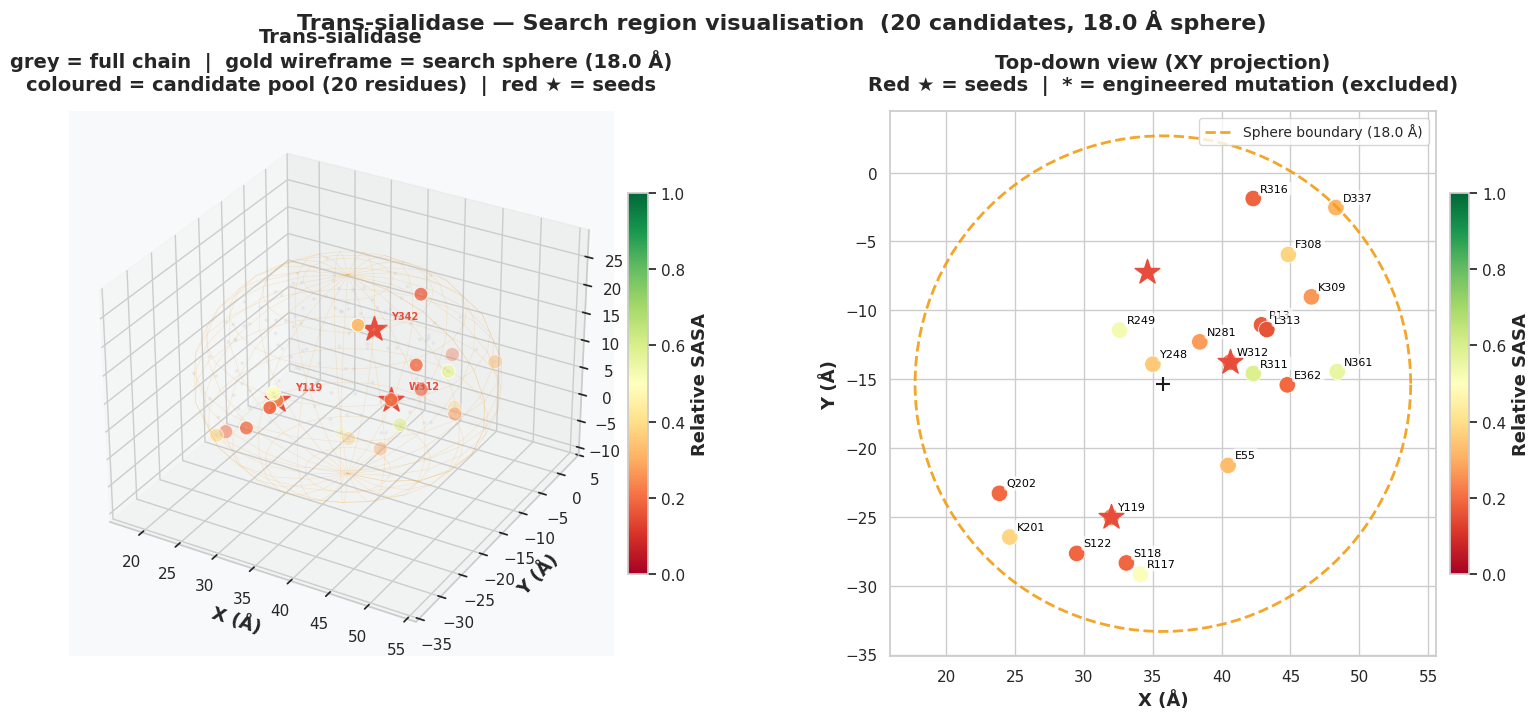

In [8]:
# Cell 4d: Visualise search region
#
# Shows the protein with the search sphere and candidate pool marked.
# Runs two views:
#   1. py3Dmol — proper 3D ribbon view (requires: pip install py3Dmol)
#   2. matplotlib — 3D scatter + top-down projection (always works)
#
# Run this cell after confirming the candidate pool in Cell 4c.

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

from mpl_toolkits.mplot3d import Axes3D

# ── py3Dmol view ────────────────────────────────────────────────────────────
try:
    import py3Dmol
    view = py3Dmol.view(width=680, height=480)
    with open(primary_pdb_path) as f:
        pdb_data = f.read()
    view.addModel(pdb_data, 'pdb')
    # Whole chain as faint grey cartoon
    view.setStyle(
        {'chain': TARGET_CHAIN},
        {'cartoon': {'color': 'lightgrey', 'opacity': 0.55}}
    )
    # Search sphere as transparent yellow surface
    view.addSphere({
        'center': {
            'x': float(seed_centre[0]),
            'y': float(seed_centre[1]),
            'z': float(seed_centre[2])
        },
        'radius': float(SPHERE_RADIUS),
        'color': 'gold',
        'opacity': 0.08,
        'wireframe': False
    })
    # Candidate pool residues as blue sticks + small spheres
    for res_num in candidate_pool:
        view.addStyle(
            {'chain': TARGET_CHAIN, 'resi': int(res_num)},
            {'stick': {'color': 'cornflowerblue', 'radius': 0.25},
             'sphere': {'color': 'cornflowerblue', 'radius': 0.5, 'opacity': 0.8}}
        )
    # Seed residues as larger red spheres
    for res_num in seed_res_nums:
        view.addStyle(
            {'chain': TARGET_CHAIN, 'resi': int(res_num)},
            {'sphere': {'color': 'red', 'radius': 1.0, 'opacity': 1.0}}
        )
    view.zoomTo({'chain': TARGET_CHAIN,
                 'resi': [int(r) for r in seed_res_nums]})
    print('py3Dmol view (blue = candidate pool, red = seeds, gold sphere = search region):')
    view.show()

except ImportError:
    print('py3Dmol not installed. Install it for a proper 3D ribbon view:')
    print('  pip install py3Dmol')
    print('Then re-run this cell.')
    print()

# ── matplotlib 3D scatter + top-down view ───────────────────────────────────
fig = plt.figure(figsize=(16, 7))

# Left panel: 3D overview
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#F8F9FA')

# All protein CA atoms — faint grey
all_xyz = sasa_df[['x', 'y', 'z']].values
ax1.scatter(all_xyz[:, 0], all_xyz[:, 1], all_xyz[:, 2],
            color='#BDC3C7', s=3, alpha=0.15, zorder=1)

# Search sphere wireframe
u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:12j]
sx = seed_centre[0] + SPHERE_RADIUS * np.cos(u) * np.sin(v)
sy = seed_centre[1] + SPHERE_RADIUS * np.sin(u) * np.sin(v)
sz = seed_centre[2] + SPHERE_RADIUS * np.cos(v)
ax1.plot_wireframe(sx, sy, sz,
                   color='#F39C12', alpha=0.20, linewidth=0.4)

# Candidate pool coloured by relative SASA
cpool = candidate_pool_df.copy()
sc1 = ax1.scatter(cpool['x'], cpool['y'], cpool['z'],
                  c=cpool['relative_sasa'], cmap=SASA_COLORMAP,
                  s=100, vmin=0, vmax=1, zorder=3,
                  edgecolors='white', linewidths=0.8)

# Seed residues as red stars
for rn in seed_res_nums:
    row = sasa_df[sasa_df['res_num'] == rn]
    if not row.empty:
        ax1.scatter(float(row['x']), float(row['y']), float(row['z']),
                    color='#E74C3C', s=350, marker='*', zorder=5)
        ax1.text(float(row['x']) + 1.5, float(row['y']) + 1.5, float(row['z']) + 1.5,
                 f"{row['res_name'].values[0]}{rn}",
                 fontsize=7, color='#E74C3C', fontweight='bold')

ax1.set_xlabel('X (Å)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Y (Å)', fontsize=13, fontweight='bold')
ax1.set_zlabel('Z (Å)', fontsize=13, fontweight='bold')
ax1.tick_params(labelsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_title(
    f'{TARGET_NAME}\n'
    f'grey = full chain  |  gold wireframe = search sphere ({SPHERE_RADIUS} Å)\n'
    f'coloured = candidate pool ({len(candidate_pool)} residues)  |  red ★ = seeds',
    fontsize=14, fontweight='bold', pad=15
)
cbar1 = plt.colorbar(sc1, ax=ax1, shrink=0.7, pad=0.02)
cbar1.set_label('Relative SASA', fontsize=13, fontweight='bold')
cbar1.ax.tick_params(labelsize=11)

# Right panel: top-down XY projection of candidate pool
ax2 = fig.add_subplot(122)

sns.scatterplot(
    data=cpool, x='x', y='y',
    hue='relative_sasa', palette=SASA_COLORMAP, hue_norm=(0, 1),
    s=140, edgecolor='white', linewidth=0.5,
    ax=ax2, legend=False, zorder=2
)
sm = plt.cm.ScalarMappable(cmap=SASA_COLORMAP, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar2 = plt.colorbar(sm, ax=ax2, shrink=0.7, pad=0.02)
cbar2.set_label('Relative SASA', fontsize=13, fontweight='bold')
cbar2.ax.tick_params(labelsize=11)

for _, row in cpool.iterrows():
    eng_tag = ' *' if row.get('engineered', False) else ''
    label = f"{row['res_name']}{int(row['res_num'])}{eng_tag}"
    ax2.annotate(
        label,
        (row['x'], row['y']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points',
        color='darkred' if row.get('engineered', False) else 'black',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
    )

# Seed residues
for rn in seed_res_nums:
    row = sasa_df[sasa_df['res_num'] == rn]
    if not row.empty:
        ax2.scatter(float(row['x']), float(row['y']),
                    color='#E74C3C', s=350, marker='*', zorder=5)

# Search sphere circle projected onto XY plane
theta = np.linspace(0, 2 * np.pi, 120)
ax2.plot(seed_centre[0] + SPHERE_RADIUS * np.cos(theta),
         seed_centre[1] + SPHERE_RADIUS * np.sin(theta),
         color='#F39C12', linewidth=2, linestyle='--', alpha=0.9,
         label=f'Sphere boundary ({SPHERE_RADIUS} Å)')
ax2.plot(*seed_centre[:2], 'k+', markersize=10, markeredgewidth=1.5)

ax2.set_xlabel('X (Å)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Y (Å)', fontsize=13, fontweight='bold')
ax2.tick_params(labelsize=11)
ax2.set_title(
    f'Top-down view (XY projection)\n'
    f'Red ★ = seeds  |  * = engineered mutation (excluded)',
    fontsize=14, fontweight='bold', pad=15
)
ax2.set_aspect('equal')
ax2.legend(fontsize=10)

plt.suptitle(
    f'{TARGET_NAME} — Search region visualisation  '
    f'({len(candidate_pool)} candidates, {SPHERE_RADIUS} Å sphere)',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()

fig_path = output_dir / f'{TARGET_LABEL}_search_region.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
pass
print(f'Figure saved: {fig_path}')
print()
print(f'Candidate pool: {sorted(candidate_pool)}')


In [9]:
# Cell 5: Epitope centre of mass
#
# The candidate pool selected in Cell 4c is what Notebook 00 (the Bayesian
# controller) explores. Here we simply fix the epitope centre of mass from the
# seed residues and expose the candidate pool for the downstream geometry and
# neighbourhood cells.

epitope_com = seed_centre.copy()
epitope_core_nums = candidate_pool
print(f'Epitope centre of mass: ({epitope_com[0]:.2f}, {epitope_com[1]:.2f}, {epitope_com[2]:.2f})')
print(f'Candidate pool size: {len(candidate_pool)} residues')
print(f'Residues: {sorted(candidate_pool)}')

# Empty core-residue table kept so the geometry cell (Cell 6) still runs;
# in this workflow geometry is computed from the seed-derived centre.
epitope_core_df = pd.DataFrame()
epitope_core_data = []


Epitope centre of mass: (35.74, -15.33, 9.20)
Candidate pool size: 20 residues
Residues: [13, 55, 117, 118, 119, 122, 201, 202, 248, 249, 281, 308, 309, 311, 312, 313, 316, 337, 361, 362]


In [10]:
# Cell 6: Epitope geometry

if not epitope_core_df.empty:
    matched = epitope_core_df if 'match' not in epitope_core_df.columns else \
              epitope_core_df[epitope_core_df['match'] == True]
else:
    matched = pd.DataFrame()

if len(matched) > 1:
    coords = matched[['x', 'y', 'z']].values

    from scipy.spatial.distance import pdist, squareform
    pairwise = squareform(pdist(coords))

    dists_from_com  = np.linalg.norm(coords - epitope_com, axis=1)
    max_spread      = dists_from_com.max()
    mean_spread     = dists_from_com.mean()

    print(f'EPITOPE GEOMETRY — {TARGET_NAME}')
    print('=' * 60)
    print(f'Centre of mass:       ({epitope_com[0]:.2f}, {epitope_com[1]:.2f}, {epitope_com[2]:.2f})')
    print(f'Max spread from COM:   {max_spread:.1f} Angstroms')
    print(f'Mean spread:           {mean_spread:.1f} Angstroms')
    print(f'Max pairwise dist:     {pairwise.max():.1f} Angstroms')
    print()

    labels = [f"{row['actual_aa']}{row['res_num']}" for _, row in matched.iterrows()]
    pw_df  = pd.DataFrame(pairwise, index=labels, columns=labels)
    print('Pairwise CA distances (Angstroms):')
    display(pw_df.round(1))
elif len(matched) == 1:
    print('Only one core residue — pairwise geometry not applicable.')
    print(f'Centre: ({epitope_com[0]:.2f}, {epitope_com[1]:.2f}, {epitope_com[2]:.2f})')
else:
    print(f'Epitope centre: ({epitope_com[0]:.2f}, {epitope_com[1]:.2f}, {epitope_com[2]:.2f})')
    print('(No core residue table — geometry computed from geometric/auto centre.)')


Epitope centre: (35.74, -15.33, 9.20)
(No core residue table — geometry computed from geometric/auto centre.)


In [11]:
# Cell 7: Find all residues in the epitope neighbourhood
#
# Collects every residue within EPITOPE_RADIUS of the epitope centre.
# This is the full region an antibody could contact.

all_ca_atoms = [
    residue['CA']
    for residue in working_chain
    if residue.get_id()[0] == ' ' and 'CA' in residue
]

ns             = NeighborSearch(all_ca_atoms)
nearby_residues = ns.search(epitope_com.tolist(), EPITOPE_RADIUS, level='R')

neighbourhood_data = []
for residue in nearby_residues:
    if residue.get_id()[0] != ' ':
        continue
    res_num    = residue.get_id()[1]
    res_name   = residue.get_resname()
    ca_coords  = residue['CA'].get_vector().get_array()
    dist_to_com = np.linalg.norm(ca_coords - epitope_com)
    in_core    = res_num in epitope_core_nums

    neighbourhood_data.append({
        'res_num':         res_num,
        'res_name':        res_name,
        'dist_to_epitope': dist_to_com,
        'in_core':         in_core,
        'x': ca_coords[0], 'y': ca_coords[1], 'z': ca_coords[2],
    })

neighbourhood_df = pd.DataFrame(neighbourhood_data).sort_values('dist_to_epitope').reset_index(drop=True)

print(f'EPITOPE NEIGHBOURHOOD — {TARGET_NAME}')
print(f'Radius: {EPITOPE_RADIUS} A from centre')
print('=' * 60)
print(f'Total residues in neighbourhood : {len(neighbourhood_df)}')
print(f'Core epitope residues           : {neighbourhood_df["in_core"].sum()}')
print(f'Surrounding residues            : {(~neighbourhood_df["in_core"]).sum()}')
print()
display(neighbourhood_df)


EPITOPE NEIGHBOURHOOD — Trans-sialidase
Radius: 15.0 A from centre
Total residues in neighbourhood : 79
Core epitope residues           : 11
Surrounding residues            : 68



,res_num,res_name,dist_to_epitope,in_core,x,y,z
0,312,TRP,6.151799,True,40.618000,-13.770000,5.786000
1,285,SER,6.888172,False,33.379002,-9.797000,5.838000
2,59,ASP,7.865102,False,35.115002,-20.726999,14.881000
3,283,PRO,8.020814,False,36.592999,-13.789000,1.370000
4,284,GLY,8.127245,False,34.282001,-11.044000,2.445000
...,...,...,...,...,...,...,...
74,63,ILE,14.692794,False,32.316002,-19.610001,22.827000
75,52,ALA,14.756124,False,34.194000,-14.683000,23.856001
76,288,SER,14.850417,False,28.410999,-2.456000,10.249000
77,203,VAL,14.899030,False,23.732000,-20.120001,1.791000


In [12]:
# Cell 9: Compare two structures (optional)
#
# If you loaded an alternate structure in Cell 3, this cell compares
# the two structures residue by residue at the candidate-pool positions.
#
# Use cases:
#   - Wild-type vs mutant: check if the epitope is conserved
#   - Apo vs holo: see conformational changes at the binding site
#   - Active vs inactive: identify conformation-specific residues

if alternate_pdb_path:
    alt_structure = parser.get_structure(f'{TARGET_LABEL}_alt', alternate_pdb_path)
    alt_model     = alt_structure[0]

    # Use the same chain ID as the primary structure (adjust if needed)
    alt_chains = [c.get_id() for c in alt_model]
    alt_chain_id = TARGET_CHAIN if TARGET_CHAIN in alt_chains else alt_chains[0]
    alt_chain  = alt_model[alt_chain_id]

    print(f'STRUCTURE COMPARISON — {TARGET_NAME}')
    print('=' * 60)
    print(f'Primary  : {Path(primary_pdb_path).name}   chain {TARGET_CHAIN}')
    print(f'Alternate: {Path(alternate_pdb_path).name}  chain {alt_chain_id}')
    print()

    # Compare across the candidate pool residues
    compare_nums = epitope_core_nums

    print(f'Comparing {len(compare_nums)} residue position(s).')
    print()
    print(f'{"Position":<10} {"Primary":<10} {"Alternate":<12} {"Same?"}')
    print('-' * 45)

    differences = []
    for res_num in sorted(compare_nums):
        primary_aa  = '---'
        alternate_aa = '---'

        try:
            primary_aa = working_chain[(' ', res_num, ' ')].get_resname()
        except KeyError:
            pass

        try:
            alternate_aa = alt_chain[(' ', res_num, ' ')].get_resname()
        except KeyError:
            try:
                alternate_aa = alt_chain[res_num].get_resname()
            except:
                pass

        same = 'YES' if primary_aa == alternate_aa else 'DIFFERENT'
        if same == 'DIFFERENT':
            differences.append(res_num)
        print(f'{res_num:<10} {primary_aa:<10} {alternate_aa:<12} {same}')

    print()
    if differences:
        print(f'Positions that differ: {differences}')
        print()
        print('TIP: If residues differ at candidate positions, the antibody may')
        print('show differential binding between the two structural states.')
        print('If residues are conserved, the antibody should bind both states.')
    else:
        print('All compared positions are identical between the two structures.')

else:
    print('No alternate structure provided. Skipping comparison.')
    print('Select an alternate PDB in Cell 3 to enable this analysis.')


STRUCTURE COMPARISON — Trans-sialidase
Primary  : 1MS3.pdb   chain A
Alternate: 1S0I.pdb  chain A

Comparing 20 residue position(s).

Position   Primary    Alternate    Same?
---------------------------------------------
13         ARG        ARG          YES
55         GLU        GLU          YES
117        ARG        ARG          YES
118        SER        SER          YES
119        TYR        TYR          YES
122        SER        SER          YES
201        LYS        LYS          YES
202        GLN        GLN          YES
248        TYR        TYR          YES
249        ARG        ARG          YES
281        ASN        ASN          YES
308        PHE        PHE          YES
309        LYS        LYS          YES
311        ARG        ARG          YES
312        TRP        TRP          YES
313        LEU        LEU          YES
316        ARG        ARG          YES
337        ASP        ASP          YES
361        ASN        ASN          YES
362        GLU        GLU          YES

In [13]:
# Cell 10: Clean and export the target PDB
#
# RFdiffusion and Boltz-2 need a clean PDB:
#   - Selected chain only
#   - Protein residues only (no waters, no ligands, no HETATM)
#   - No alternate conformations (keep A or blank)

class CleanProteinSelect(Select):
    """Select protein residues from one chain; drop waters, ligands, altlocs."""
    def __init__(self, chain_id):
        self.chain_id = chain_id

    def accept_chain(self, chain):
        return chain.get_id() == self.chain_id

    def accept_residue(self, residue):
        return residue.get_id()[0] == ' '   # space = standard amino acid

    def accept_atom(self, atom):
        altloc = atom.get_altloc()
        return altloc == ' ' or altloc == 'A'

pdb_stem     = Path(primary_pdb_path).stem
clean_pdb_path = output_dir / f'{pdb_stem}_chain{TARGET_CHAIN}_clean.pdb'

io = PDBIO()
io.set_structure(structure)
io.save(str(clean_pdb_path), CleanProteinSelect(TARGET_CHAIN))

# Verify
clean_struct    = parser.get_structure('clean', str(clean_pdb_path))
clean_chain     = clean_struct[0][TARGET_CHAIN]
clean_residues  = [r for r in clean_chain if r.get_id()[0] == ' ']

print(f'CLEANED TARGET PDB — {TARGET_NAME}')
print('=' * 60)
print(f'Output file : {clean_pdb_path}')
print(f'Chain       : {TARGET_CHAIN}')
print(f'Residues    : {len(clean_residues)}')
print(f'Range       : {clean_residues[0].get_id()[1]} — {clean_residues[-1].get_id()[1]}')
print()
print('This file is ready for RFdiffusion and Boltz-2.')


CLEANED TARGET PDB — Trans-sialidase
Output file : /mnt/c/Antibody Design/1MS3_chainA_clean.pdb
Chain       : A
Residues    : 623
Range       : 1 — 632

This file is ready for RFdiffusion and Boltz-2.


In [14]:
# Cell 11: Save all analysis outputs

# 1. Core epitope residues CSV (only if a core table was built)
if not epitope_core_df.empty:
    core_csv = output_dir / f'{TARGET_LABEL}_epitope_core.csv'
    epitope_core_df.to_csv(core_csv, index=False)
    print(f'Core epitope CSV   : {core_csv}')

# 2. Full neighbourhood CSV
neighbourhood_csv = output_dir / f'{TARGET_LABEL}_epitope_neighbourhood.csv'
neighbourhood_df.to_csv(neighbourhood_csv, index=False)
print(f'Neighbourhood CSV  : {neighbourhood_csv}')

# 3. Candidate pool JSON (input for Notebook 00 / Notebook 02)
hotspot_json_path = output_dir / f'{TARGET_LABEL}_hotspot_residues.json'
hotspot_data = {
    'target_name':      TARGET_NAME,
    'source_pdb':       Path(primary_pdb_path).name,
    'chain':            TARGET_CHAIN,
    'seed_residues':    seed_res_nums,
    'sphere_radius':    SPHERE_RADIUS,
    'sasa_threshold':   SASA_THRESHOLD_VAL,
    'epitope_com':      epitope_com.tolist(),
    'candidate_pool':   sorted(candidate_pool),
    'hotspot_residues': sorted(candidate_pool),
    'n_candidates':     len(candidate_pool),
    'clean_pdb':        str(clean_pdb_path),
}
with open(hotspot_json_path, 'w') as f:
    json.dump(hotspot_data, f, indent=2)
print(f'Candidate pool JSON: {hotspot_json_path}')

# 4. Epitope centre of mass (plain text for tools that need raw coords)
com_file = output_dir / f'{TARGET_LABEL}_epitope_com.txt'
com_file.write_text(f'{epitope_com[0]:.3f} {epitope_com[1]:.3f} {epitope_com[2]:.3f}\n')
print(f'Epitope COM        : {com_file}')

print()
print('=' * 60)
print(f'NOTEBOOK 01 COMPLETE — {TARGET_NAME}')
print('=' * 60)
print()
print(f'  Source PDB            : {Path(primary_pdb_path).name}')
print(f'  Chain                 : {TARGET_CHAIN}')
print(f'  Seed residues         : {seed_res_nums}')
print(f'  Sphere radius         : {SPHERE_RADIUS} A')
print(f'  SASA threshold        : {SASA_THRESHOLD_VAL}')
print(f'  Candidate pool size   : {len(candidate_pool)}')
print(f'  Neighbourhood residues: {len(neighbourhood_df)}')
print(f'  Clean PDB             : {clean_pdb_path}')
print()
print('Next: Notebook 00 (Bayesian controller) explores this candidate pool,')
print('and Notebook 02 designs binders for each trial combination using the')
print('clean PDB and hotspot_residues.json.')


Neighbourhood CSV  : /mnt/c/Antibody Design/ts_epitope_neighbourhood.csv
Candidate pool JSON: /mnt/c/Antibody Design/ts_hotspot_residues.json
Epitope COM        : /mnt/c/Antibody Design/ts_epitope_com.txt

NOTEBOOK 01 COMPLETE — Trans-sialidase

  Source PDB            : 1MS3.pdb
  Chain                 : A
  Seed residues         : [342, 119, 312]
  Sphere radius         : 18.0 A
  SASA threshold        : 0.15
  Candidate pool size   : 20
  Neighbourhood residues: 79
  Clean PDB             : /mnt/c/Antibody Design/1MS3_chainA_clean.pdb

Next: Notebook 00 (Bayesian controller) explores this candidate pool,
and Notebook 02 designs binders for each trial combination using the
clean PDB and hotspot_residues.json.


Figure saved: /mnt/c/Antibody Design/ts_epitope_analysis.png


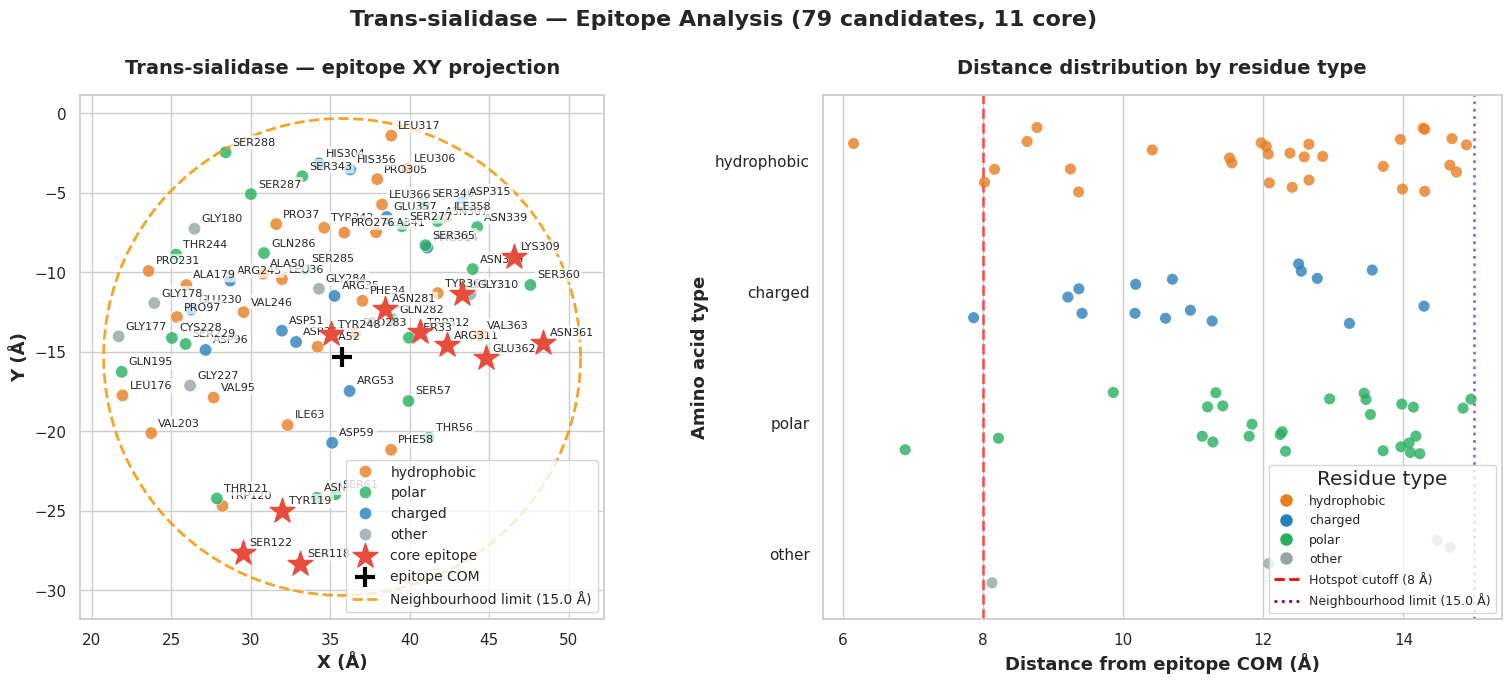

In [15]:
# Cell 12: Visualise epitope (2D projection)

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

# Classify residues by amino-acid type for colouring. (Previously computed in
# the old hotspot cell, which has been removed; done here so the plots stand
# alone.)
HYDROPHOBIC_AA = {'ALA', 'VAL', 'LEU', 'ILE', 'PRO', 'PHE', 'TRP', 'MET', 'TYR'}
CHARGED_AA     = {'ARG', 'LYS', 'ASP', 'GLU', 'HIS'}
POLAR_AA       = {'SER', 'THR', 'ASN', 'GLN', 'CYS'}
if 'aa_type' not in neighbourhood_df.columns:
    neighbourhood_df['aa_type'] = neighbourhood_df['res_name'].apply(
        lambda x: 'hydrophobic' if x in HYDROPHOBIC_AA
        else 'charged'     if x in CHARGED_AA
        else 'polar'       if x in POLAR_AA
        else 'other'
    )

# Map the chemical aa_type buckets onto the shared CATEGORY_COLORS palette.
# Charged residues are almost always solvent-facing, so they borrow the
# 'surface' colour; anything uncategorised borrows 'unknown'.
AA_TYPE_COLORS = {
    'hydrophobic': CATEGORY_COLORS['hydrophobic'],
    'charged':     CATEGORY_COLORS['surface'],
    'polar':       CATEGORY_COLORS['polar'],
    'other':       CATEGORY_COLORS['unknown'],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: XY projection coloured by amino acid type ---
ax = axes[0]
sns.scatterplot(
    data=neighbourhood_df, x='x', y='y',
    hue='aa_type', palette=AA_TYPE_COLORS,
    s=80, alpha=0.8, edgecolor='white', linewidth=0.5,
    ax=ax, zorder=2
)

for _, row in neighbourhood_df.iterrows():
    ax.annotate(
        f"{row['res_name']}{row['res_num']}",
        (row['x'], row['y']), fontsize=8,
        xytext=(5, 5), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
    )

# Highlight core epitope residues
core_rows = neighbourhood_df[neighbourhood_df['in_core']]
if not core_rows.empty:
    ax.scatter(core_rows['x'], core_rows['y'],
               color='#E74C3C', s=350, marker='*', label='core epitope', zorder=5)

# Mark epitope COM
ax.scatter(epitope_com[0], epitope_com[1],
           c='black', s=220, marker='+', linewidths=3, label='epitope COM', zorder=6)

# Neighbourhood-radius boundary projected onto XY plane
theta = np.linspace(0, 2 * np.pi, 120)
ax.plot(epitope_com[0] + EPITOPE_RADIUS * np.cos(theta),
        epitope_com[1] + EPITOPE_RADIUS * np.sin(theta),
        color='#F39C12', linewidth=2, linestyle='--', alpha=0.9,
        label=f'Neighbourhood limit ({EPITOPE_RADIUS} Å)')

ax.set_xlabel('X (Å)', fontsize=13, fontweight='bold')
ax.set_ylabel('Y (Å)', fontsize=13, fontweight='bold')
ax.tick_params(labelsize=11)
ax.set_title(f'{TARGET_NAME} — epitope XY projection', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_aspect('equal')

# --- Plot 2: Distance distribution ---
ax = axes[1]
sns.stripplot(
    data=neighbourhood_df, x='dist_to_epitope', y='aa_type',
    hue='aa_type', palette=AA_TYPE_COLORS,
    order=['hydrophobic', 'charged', 'polar', 'other'],
    size=8, alpha=0.8, jitter=0.25, ax=ax, legend=False
)

ax.axvline(x=8.0,  color='red',    linestyle='--', linewidth=2, alpha=0.6)
ax.axvline(x=EPITOPE_RADIUS, color='purple', linestyle=':', linewidth=2, alpha=0.6)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', color=AA_TYPE_COLORS[k],
           label=k, markersize=8)
    for k in ['hydrophobic', 'charged', 'polar', 'other']
]
legend_handles += [
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Hotspot cutoff (8 Å)'),
    Line2D([0], [0], color='purple', linestyle=':', linewidth=2,
           label=f'Neighbourhood limit ({EPITOPE_RADIUS} Å)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right', title='Residue type')

ax.set_xlabel('Distance from epitope COM (Å)', fontsize=13, fontweight='bold')
ax.set_ylabel('Amino acid type', fontsize=13, fontweight='bold')
ax.tick_params(labelsize=11)
ax.set_title('Distance distribution by residue type', fontsize=14, fontweight='bold', pad=15)

plt.suptitle(
    f'{TARGET_NAME} — Epitope Analysis '
    f'({len(neighbourhood_df)} candidates, {core_rows.shape[0]} core)',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()

fig_path = output_dir / f'{TARGET_LABEL}_epitope_analysis.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
pass
print(f'Figure saved: {fig_path}')
